# Investigating Differences In VRP Between SPX and NDAQ
in this notebook I compare the VRP's over time between the S&P 500 

In [126]:
import matplotlib.pyplot as plt
import pandas as pd   
import yfinance as yf
import numpy as np
import statsmodels.api as sm
import statistics
from arch import arch_model

In [127]:
spx = yf.download("^GSPC", start="1995-01-01", end="2026-08-01")
vix = yf.download("^VIX", start="1995-01-01", end="2026-08-01")
ndaq = yf.download("NDAQ", start="1995-01-01", end="2026-08-01")
vxn = yf.download("^VIX", start="1995-01-01", end="2026-08-01")

prices_ndaq = ndaq["Close"].squeeze()
prices_vxn = vxn["Close"].squeeze()
prices_spx = spx["Close"].squeeze()
prices_vix = vix["Close"].squeeze()

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


# What Distrubtion Does Vol Follow
You would expect Nasdaq to have a higher mode due to the idea of 'hype', lack of profits, and other factors.

0.1752287913805824


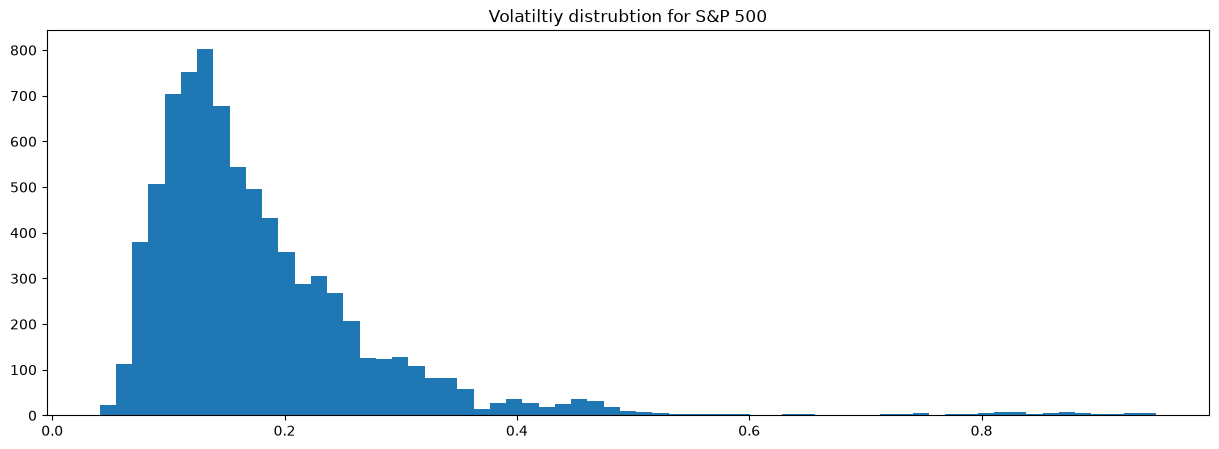

In [165]:
log_return_spx_daily = np.log(prices_spx).diff()
log_return_spx_mean = log_return_spx_daily.mean()
ri_minus_rmean_spx = ((log_return_spx_daily) - log_return_spx_mean ) **2
sum_ri_minus_rmean_spx = (((log_return_spx_daily) - log_return_spx_mean ) **2).rolling(10).sum()
var_spx = (1/(len(log_return_spx_daily) -1) * sum_ri_minus_rmean_spx) * (252/10)
vol_spx = np.sqrt(var_spx) * 100
print(vol_spx.mean())
plt.figure(figsize=(15,5))
plt.hist(vol, bins=65)
plt.title("Volatiltiy distrubtion for S&P 500")

plt.show()

0.38229157299370126


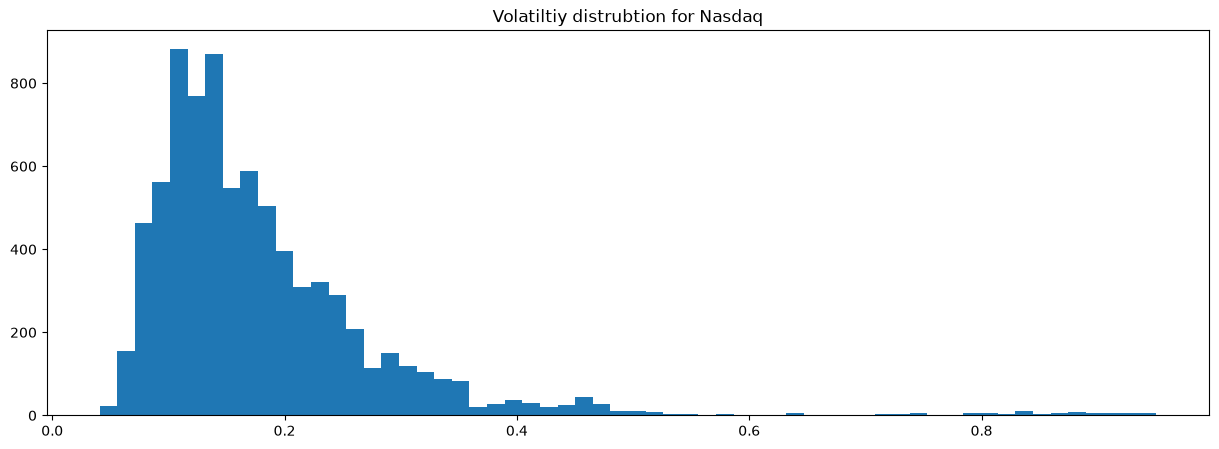

In [164]:
log_return_ndaq_daily = np.log(prices_ndaq).diff()
log_return_ndaq_mean = log_return_ndaq_daily.mean()
ri_minus_rmean_ndaq = ((log_return_ndaq_daily) - log_return_ndaq_mean ) **2
sum_ri_minus_rmean_ndaq = (((log_return_ndaq_daily) - log_return_ndaq_mean ) **2).rolling(10).sum()
var_ndaq = (1/(len(log_return_ndaq_daily) -1) * sum_ri_minus_rmean_ndaq) * (252/10)
vol_ndaq = np.sqrt(var_ndaq) * 100
print(vol_ndaq.mean())
plt.figure(figsize=(15, 5))
plt.hist(vol, bins=65)
plt.title("Volatiltiy distrubtion for Nasdaq")

plt.show()

# Modelling future Volatitlity

Test for volatility clustering using autocorrelation function test(ACF) to see if volatility clustering appears. Youtube has been vaslty useful during this, I cannot recommend it enough as a learning resource.

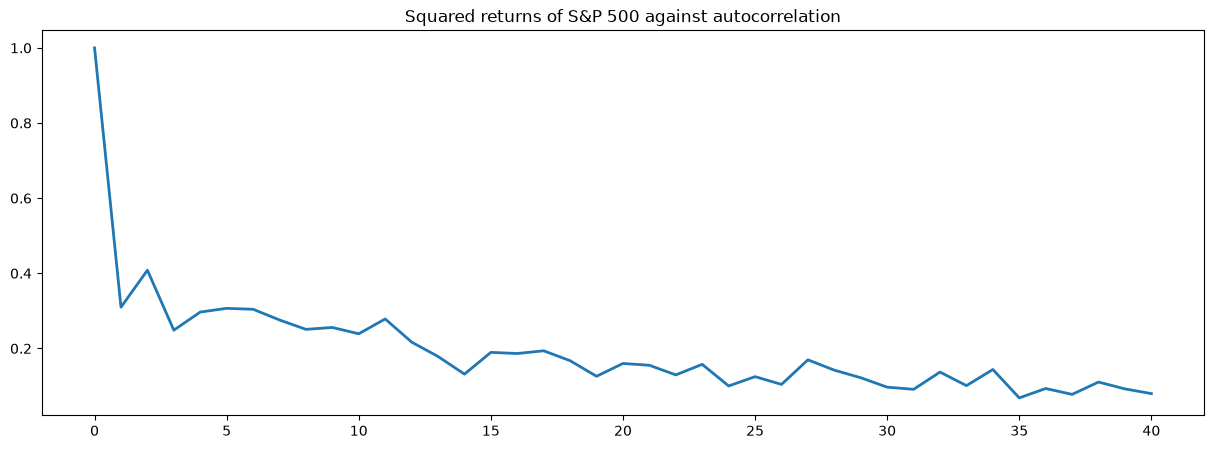

In [199]:
from statsmodels.graphics.tsaplots import acf
ln_rets_spx = log_return_spx_daily.dropna()
squared_spx_returns = ln_rets_spx ** 2
acf_spx_values = acf(squared_spx_returns, nlags=40)
plt.figure(figsize=(15,5))
plt.plot(acf_spx_values, linewidth=2)
plt.title("Squared returns of S&P 500 against autocorrelation")
plt.show()

now the same for Nasdaq

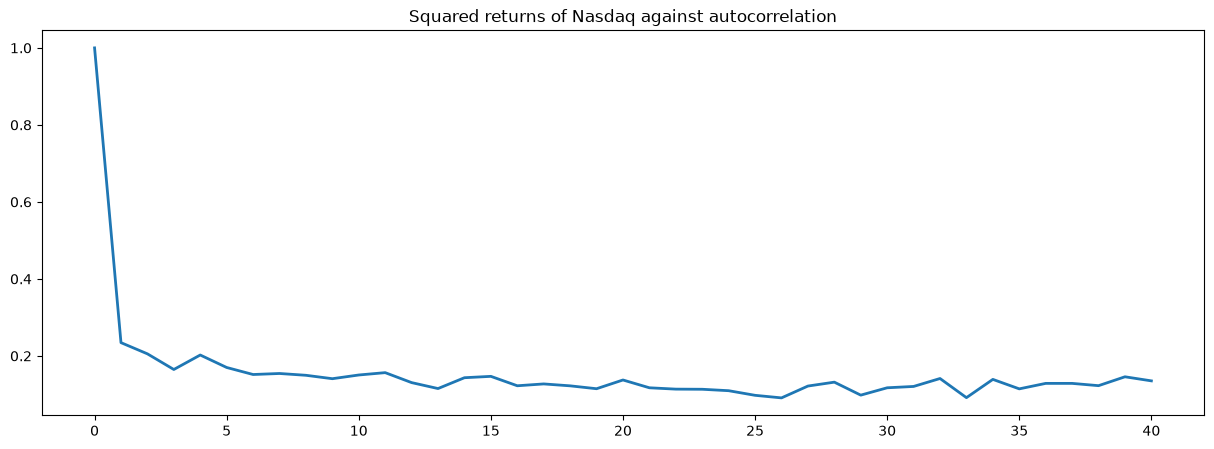

In [200]:
ln_rets_ndaq = log_return_ndaq_daily.dropna()
squared_ndaq_returns = ln_rets_ndaq ** 2
acf_ndaq_values = acf(squared_ndaq_returns, nlags=40)
plt.figure(figsize=(15,5))
plt.plot(acf_ndaq_values, linewidth=2)
plt.title("Squared returns of Nasdaq against autocorrelation")
plt.show()

In [217]:
# Use GARCH to forecast variance, I am going to keep everything in variance points for now 
returns_spx = 100 * prices_spx.pct_change().dropna()
model = arch_model(returns_spx, vol='Garch', p=1, q=1, dist='normal')
result = model.fit()

forecast = result.forecast(horizon=21)
daily_var_spx_forecast = forecast.variance.iloc[-1]
var_spx_forecast = (daily_var_spx_forecast.sum())* (1/1000)
print(var_spx_forecast)

Iteration:      1,   Func. Count:      6,   Neg. LLF: 862188928964343.4
Iteration:      2,   Func. Count:     15,   Neg. LLF: 210940646.38505068
Iteration:      3,   Func. Count:     22,   Neg. LLF: 15328.481764155234
Iteration:      4,   Func. Count:     29,   Neg. LLF: 117279.9653930216
Iteration:      5,   Func. Count:     36,   Neg. LLF: 10932.280556637095
Iteration:      6,   Func. Count:     42,   Neg. LLF: 20444.868816557893
Iteration:      7,   Func. Count:     49,   Neg. LLF: 10859.015800331235
Iteration:      8,   Func. Count:     55,   Neg. LLF: 10841.901628271211
Iteration:      9,   Func. Count:     60,   Neg. LLF: 10841.882160758109
Iteration:     10,   Func. Count:     65,   Neg. LLF: 10841.88162363461
Iteration:     11,   Func. Count:     70,   Neg. LLF: 10841.881602638658
Iteration:     12,   Func. Count:     74,   Neg. LLF: 10841.881602641266
Optimization terminated successfully    (Exit mode 0)
            Current function value: 10841.881602638658
            Iterat

In an anthoer notebook I am trying to identify a way to improve volailtity forecasts for nasdaq volatility

In [218]:
returns_ndaq = 100 * prices_ndaq.pct_change().dropna()
model = arch_model(returns_ndaq, vol='EGarch', p=1, o=1 ,q=1, dist='t')
result = model.fit()

forecast = result.forecast(horizon=21, method='simulation', simulations=10000)
daily_var_ndaq_forecast = forecast.variance.iloc[-1]
var_ndaq_forecast = daily_var_ndaq_forecast.sum()* (1/1000)
print(var_ndaq_forecast)

Iteration:      1,   Func. Count:      8,   Neg. LLF: 48402.75260734424
Iteration:      2,   Func. Count:     21,   Neg. LLF: 33332.83996101891
Iteration:      3,   Func. Count:     32,   Neg. LLF: 112939.88710315694
Iteration:      4,   Func. Count:     44,   Neg. LLF: 41650.88124163124
Iteration:      5,   Func. Count:     55,   Neg. LLF: 15896.48705609752
Iteration:      6,   Func. Count:     63,   Neg. LLF: 11873.421526924805
Iteration:      7,   Func. Count:     71,   Neg. LLF: 15756.134911596728
Iteration:      8,   Func. Count:     79,   Neg. LLF: 11845.084729072427
Iteration:      9,   Func. Count:     86,   Neg. LLF: 11845.083129826111
Iteration:     10,   Func. Count:     94,   Neg. LLF: 11845.069463234831
Iteration:     11,   Func. Count:    101,   Neg. LLF: 11845.069424859572
Iteration:     12,   Func. Count:    107,   Neg. LLF: 11845.069424859577
Optimization terminated successfully    (Exit mode 0)
            Current function value: 11845.069424859572
            Iterati

# Using the VIX as a proxy for the fair strike and Defining Our VRP

In [219]:
window = 21 

Kvar_spx = ((prices_vix / 100) ** 2 ) **(window / 252)
Kvar_ndaq = ((prices_vxn / 100) ** 2) **(window / 252)
print(Kvar_spx.mean())

0.7570649288679936


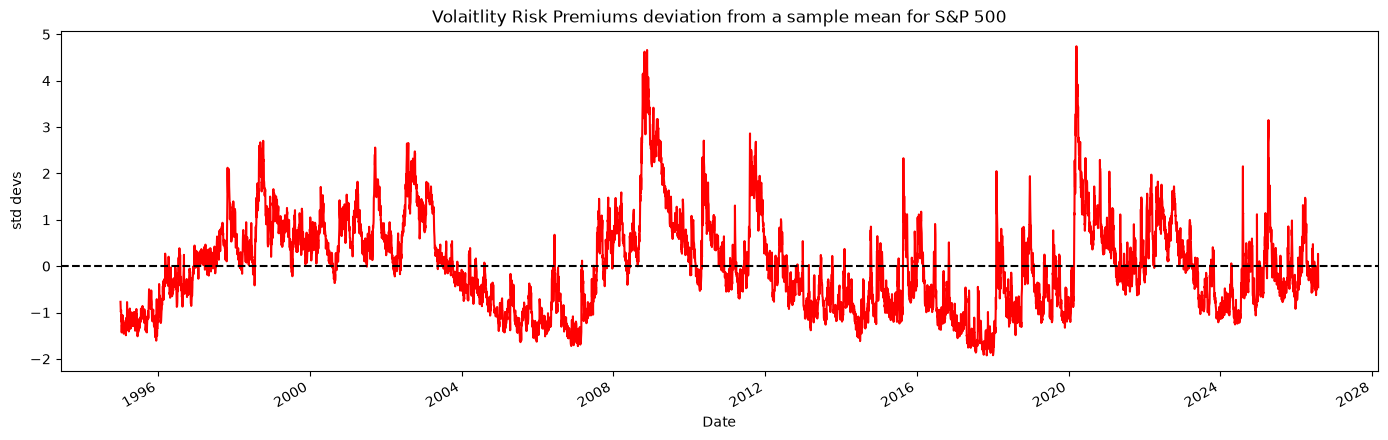

In [220]:
# Now we can define The Volatility Risk Premium
VRP_spx = Kvar_spx - var_spx_forecast
VRP_spx_mean_z_score = ((VRP_spx-VRP_spx.mean())/ VRP_spx.std()).dropna()
VRP_spx_mean_z_score.plot(title='Volaitlity Risk Premiums deviation from a sample mean for S&P 500', ylabel='std devs', color='Red' , figsize=(17,5),)
plt.axhline(0, linestyle = "--", color = 'black')

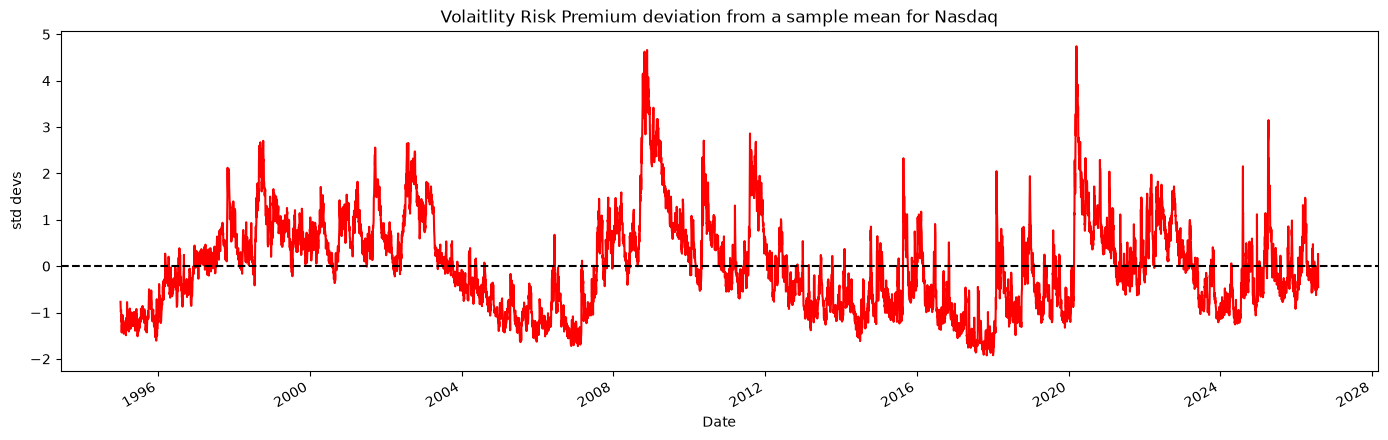

In [221]:
VRP_ndaq = Kvar_ndaq - var_ndaq_forecast
VRP_ndaq_mean_z_score = ((VRP_ndaq-VRP_ndaq.mean())/ VRP_ndaq.std()).dropna()
VRP_ndaq_mean_z_score.plot(title='Volaitlity Risk Premium deviation from a sample mean for Nasdaq', ylabel='std devs', color='Red' , figsize=(17,5),)
plt.axhline(0, linestyle = "--", color = 'black')

## Compare the log of the difference between the two VRPs over time 


<Axes: title={'center': 'VRP as & of implied vol for S&P 500'}, xlabel='Date', ylabel='% of implied vol'>

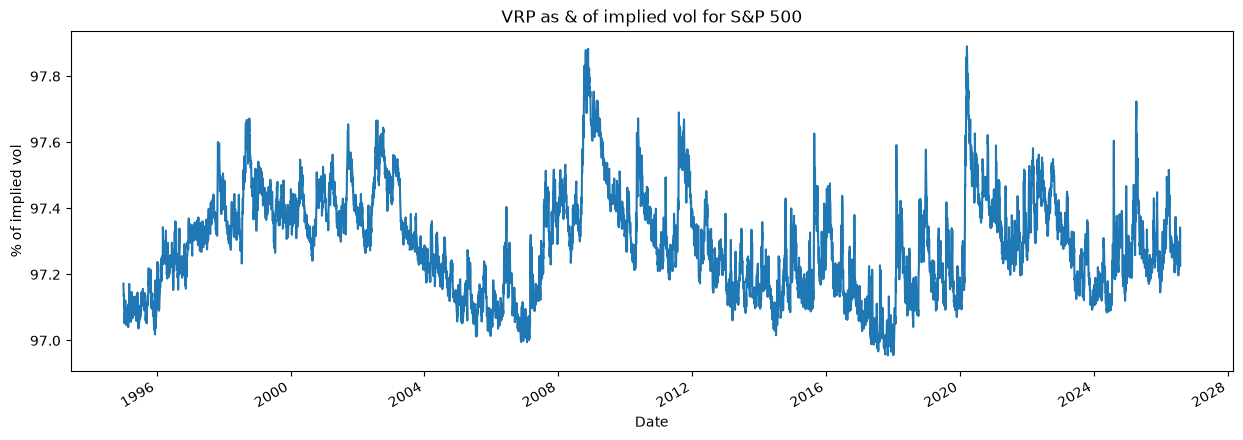

In [222]:
VRP_spx_ratio = (VRP_spx /  Kvar_spx) * (100)
VRP_spx_ratio.plot(title='VRP as & of implied vol for S&P 500', figsize=(15,5), ylabel = '% of implied vol')

<Axes: title={'center': 'VRP as & of implied vol for Nasdaq'}, xlabel='Date', ylabel='% of implied vol'>

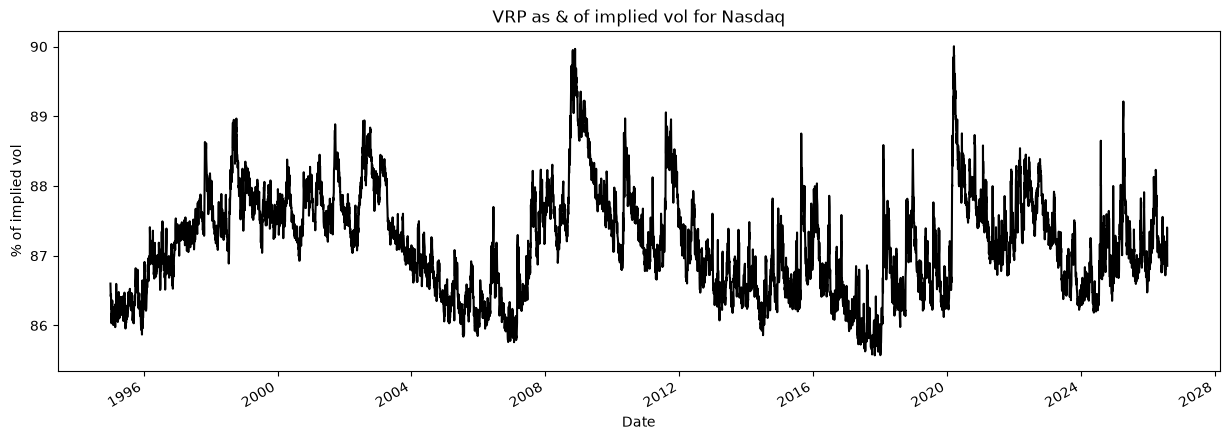

In [226]:
VRP_spx_ratio = (VRP_ndaq /  Kvar_ndaq) * (100)
VRP_spx_ratio.plot(title='VRP as & of implied vol for Nasdaq', figsize=(15,5), ylabel = '% of implied vol', color='Black')

# Correlation Between The Two VRPs
You would of course hypotheises as we approach the 2020s big tech and concentration risk starts to appear in the S&P 500

<Axes: title={'center': "Correlation between S&P 500's and Nasdaq's VRP"}, xlabel='Date'>

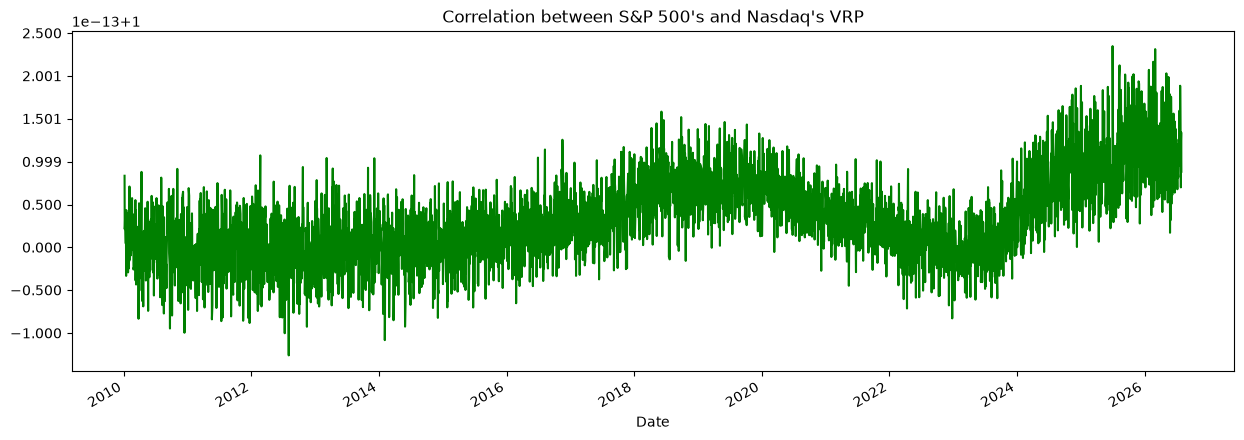

In [224]:
corr_between_VRP = VRP_spx.rolling(252*15).corr(VRP_ndaq)
corr_between_VRP.plot(title="Correlation between S&P 500's and Nasdaq's VRP",figsize=(15,5), color='Green')

Now lets look at the correlation between the Nasdaq and S&P 500s returns over this time frame

<Axes: title={'center': 'Correlation between S&P 500 and Nasdaq'}, xlabel='Date'>

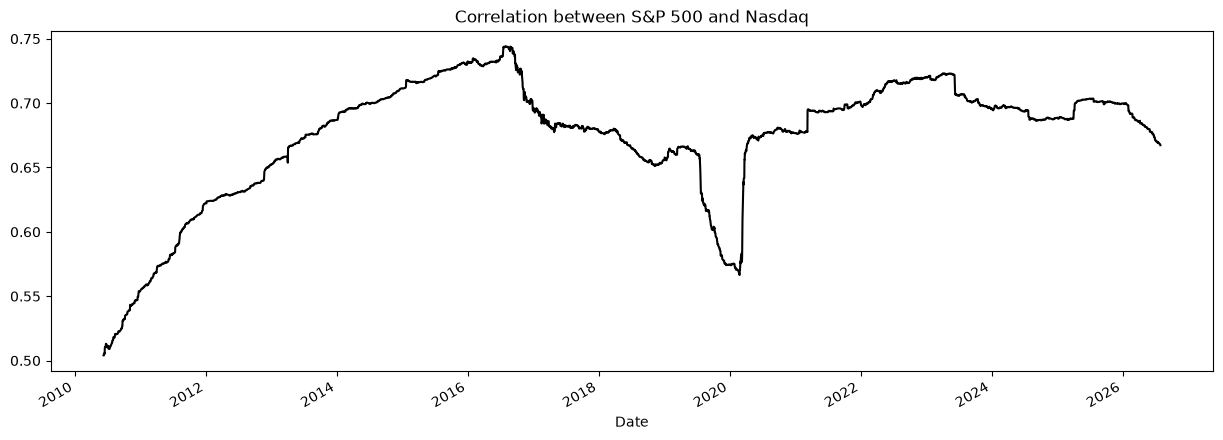

In [225]:
corr_between_ndaq_spx = log_return_spx_daily.rolling(2000).corr(log_return_ndaq_daily)
corr_between_ndaq_spx.plot(title="Correlation between S&P 500 and Nasdaq",figsize=(15,5), color='Black')